In [1]:
import numpy as np
import pandas as pd
from scipy import stats

from core.dgp import SkewTInnov,StudentTInnov

import matplotlib.pyplot as plt


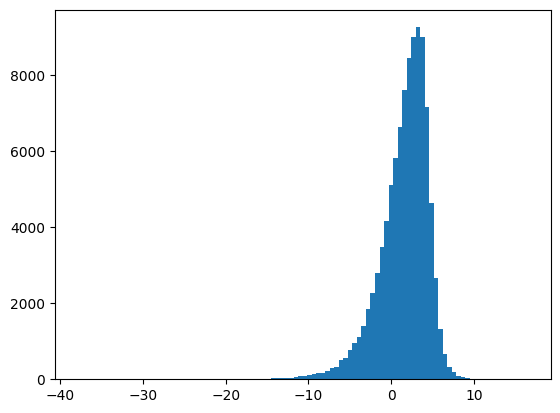

In [33]:
m = SkewTInnov(df=6, eta=-0.5, mean=0).calibrate_params(1.5,3)
rng = np.random.default_rng(42)
sample = m(100000, rng)
plt.hist(sample,bins=100);

In [34]:
sample.mean(), sample.std()

(np.float64(1.5023154310822482), np.float64(3.010815335542955))

In [35]:
stats.kurtosis(sample, fisher=True),stats.skew(sample)

(np.float64(5.652771652685052), np.float64(-1.4942856452106406))

In [36]:
m.calculate_theo_moments()
m.get_theo_moments()

{'skew': np.float64(-1.4730905016951865),
 'exc_kurt': np.float64(6.099722991689751),
 'rho': 0.0,
 'nu': 6,
 'mean': 1.5,
 'sigma': 3}

In [37]:
from arch.univariate import (
    ARX,
    ConstantMean,
    ConstantVariance,
    GARCH,
    GeneralizedError,
    Normal,
    SkewStudent,
    StudentsT,
)

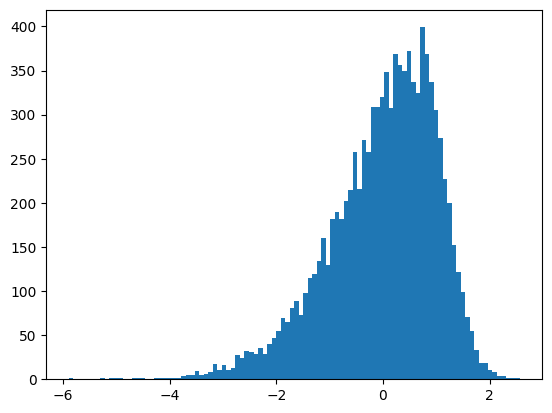

In [26]:
from arch.univariate import ConstantMean, ConstantVariance, SkewStudent

model = ConstantMean()
model.volatility = ConstantVariance()
model.distribution = SkewStudent()

params = np.array([0.0, 1, 30, -0.5])

sim = model.simulate(params, 10000)

y = sim['data']
plt.hist(y,bins=100);


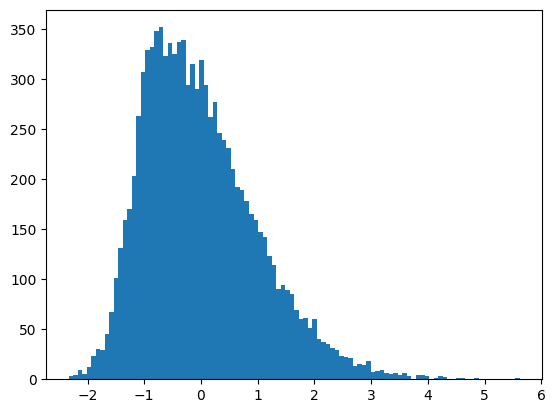

In [43]:
rng = np.random.default_rng(42)
aux = SkewStudent(seed=rng)
y = aux.simulate([50, 0.5])(10000)
plt.hist(y,bins=100); 

In [44]:
stats.kurtosis(y),stats.skew(y)

(np.float64(0.7334457425793381), np.float64(0.7928602519578309))

In [ ]:
from arch import arch_model

arch_model(None,mean='constant',vol='constant', dist='skewt')

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller, kpss, acf



In [36]:
rng = np.random.default_rng(43)
x = rng.normal(0.05, 1.0, 500)
lb = acorr_ljungbox(x, lags=[1], return_df=True)

In [37]:
lb

,lb_stat,lb_pvalue
1,2.072323,0.149993


In [40]:
import numpy as np
from statsmodels.stats.diagnostic import acorr_ljungbox

rng = np.random.default_rng(42)

count = 0
N = 1000

for _ in range(N):
    x = rng.normal(0.05, 1.0, 5000)
    pval = acorr_ljungbox(x, lags=10, return_df=True)['lb_pvalue'].iloc[-1]
    if pval < 0.05:
        count += 1

print(count / N)

0.061
